In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: test_nonlenses/17760.npy  
  inflating: __MACOSX/test_nonlenses/._17760.npy  
  inflating: test_nonlenses/18453.npy  
  inflating: __MACOSX/test_nonlenses/._18453.npy  
  inflating: test_nonlenses/5227.npy  
  inflating: __MACOSX/test_nonlenses/._5227.npy  
  inflating: test_nonlenses/4139.npy  
  inflating: __MACOSX/test_nonlenses/._4139.npy  
  inflating: test_nonlenses/3656.npy  
  inflating: __MACOSX/test_nonlenses/._3656.npy  
  inflating: test_nonlenses/11311.npy  
  inflating: __MACOSX/test_nonlenses/._11311.npy  
  inflating: test_nonlenses/3130.npy  
  inflating: __MACOSX/test_nonlenses/._3130.npy  
  inflating: test_nonlenses/11477.npy  
  inflating: __MACOSX/test_nonlenses/._11477.npy  
  inflating: test_nonlenses/16318.npy  
  inflating: __MACOSX/test_nonlenses/._16318.npy  
  inflating: test_nonlenses/17006.npy  
  inflating: __MACOSX/test_nonlenses/._17006.npy  
  inflating: test_nonlenses/18335.npy  
  infla

In [3]:
import os
os.listdir("/content/drive/MyDrive/")

['Colab Notebooks',
 'Screenshot_20250210-111748.png',
 'Screenshot_20250207-143353 (1).png',
 'Screenshot_20250406-233043.png',
 'Screenshot_20250315-012705.png',
 'Screenshot_20250207-143353.png',
 'Screenshot_20250226-135523.png',
 'Screenshot_20250226-135445.png',
 'Screenshot_20250210-111908.png',
 'Screenshot_20250226-135344.png',
 'Screenshot_20250210-111821.png',
 'Screenshot_20250406-233051.png',
 'Screenshot_20250306-113426.png',
 'Solutions_to_I.E._Irodovs_problems_in_general_phy_2062913_(z-lib.org).pdf',
 'ZLibrary',
 'IMG_20210813_081855_184.mp4',
 'https:  www.ins.txt',
 'IMG-20220509-WA0009.pdf',
 'mole concept dpp 4.pdf',
 'DocScanner 29-Sep-2022 10-21 am.pdf',
 '630c56cdf3550a00180f8396_##_Short Practice Test 01 : Maths || (Prayas 2.0 2023).pdf',
 '6330a1b10df98000116cfef1_##_Ranker Test 01 : Chemistry || (Prayas 2.0 2023).pdf',
 '6330a18daa820c0011bc12c2_##_Ranker Test 01 : Physics || (Prayas 2.0 2023).pdf',
 '6327f3c93463fb0011f979ec_##_Practice Test 02 : Chemistry |

In [4]:
!unzip "/content/drive/MyDrive/dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/test_nonlenses/._2548.npy  
  inflating: test_nonlenses/17760.npy  
  inflating: __MACOSX/test_nonlenses/._17760.npy  
  inflating: test_nonlenses/18453.npy  
  inflating: __MACOSX/test_nonlenses/._18453.npy  
  inflating: test_nonlenses/5227.npy  
  inflating: __MACOSX/test_nonlenses/._5227.npy  
  inflating: test_nonlenses/4139.npy  
  inflating: __MACOSX/test_nonlenses/._4139.npy  
  inflating: test_nonlenses/3656.npy  
  inflating: __MACOSX/test_nonlenses/._3656.npy  
  inflating: test_nonlenses/11311.npy  
  inflating: __MACOSX/test_nonlenses/._11311.npy  
  inflating: test_nonlenses/3130.npy  
  inflating: __MACOSX/test_nonlenses/._3130.npy  
  inflating: test_nonlenses/11477.npy  
  inflating: __MACOSX/test_nonlenses/._11477.npy  
  inflating: test_nonlenses/16318.npy  
  inflating: __MACOSX/test_nonlenses/._16318.npy  
  inflating: test_nonlenses/17006.npy  
  inflating: __MACOSX/test_nonlenses/._17006.npy

In [5]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir):
        self.files = []

        for f in os.listdir(lens_dir):
            if f.endswith(".npy"):
                self.files.append((os.path.join(lens_dir, f), 1))

        for f in os.listdir(nonlens_dir):
            if f.endswith(".npy"):
                self.files.append((os.path.join(nonlens_dir, f), 0))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file, label = self.files[idx]

        data = np.load(file)
        data = torch.tensor(data, dtype=torch.float32)

        return data, label

In [6]:
train_dataset = LensDataset("train_lenses", "train_nonlenses")
test_dataset = LensDataset("test_lenses", "test_nonlenses")

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
x, y = train_dataset[0]
print(x.shape, y)

torch.Size([3, 64, 64]) 1


In [9]:
import torch.nn.functional as F


In [10]:
data = np.load(file)
data = torch.tensor(data, dtype=torch.float32)

# 🔥 ADD THIS LINE
data = F.interpolate(data.unsqueeze(0), size=(224, 224)).squeeze(0)

NameError: name 'file' is not defined

In [11]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os
import torch.nn.functional as F

class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir):
        self.files = []

        for f in os.listdir(lens_dir):
            if f.endswith(".npy"):
                self.files.append((os.path.join(lens_dir, f), 1))

        for f in os.listdir(nonlens_dir):
            if f.endswith(".npy"):
                self.files.append((os.path.join(nonlens_dir, f), 0))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file, label = self.files[idx]

        data = np.load(file)
        data = torch.tensor(data, dtype=torch.float32)

        # 🔥 RESIZE HERE (INSIDE FUNCTION)
        data = F.interpolate(data.unsqueeze(0), size=(224, 224)).squeeze(0)

        return data, label

In [12]:
train_dataset = LensDataset("train_lenses", "train_nonlenses")
test_dataset = LensDataset("test_lenses", "test_nonlenses")

In [13]:
x, y = train_dataset[0]
print(x.shape)

torch.Size([3, 224, 224])


In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of lens

        y_true.extend(labels.numpy())
        y_scores.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NameError: name 'model' is not defined

In [15]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

NameError: name 'models' is not defined

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [17]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


NameError: name 'device' is not defined

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [19]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

In [20]:
class_weights = torch.tensor([1.0, 3.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
for epoch in range(5):
    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 211.2936
Epoch 2, Loss: 186.5862
Epoch 3, Loss: 147.9166
Epoch 4, Loss: 140.9190
Epoch 5, Loss: 156.6716


AUC Score: 0.9563887735668769


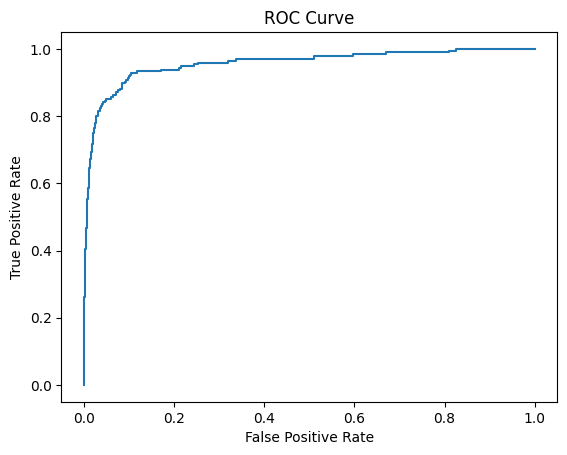

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]

        y_true.extend(labels.numpy())
        y_scores.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

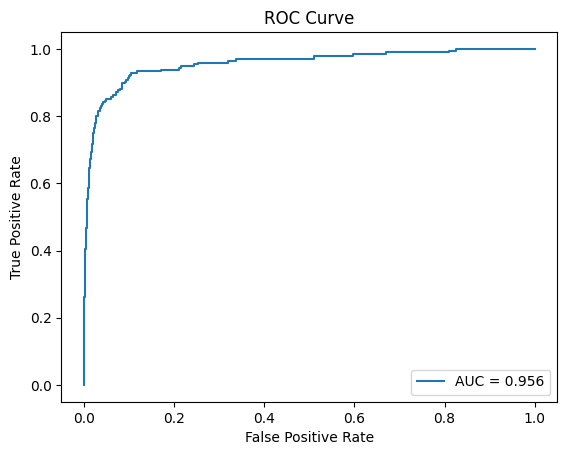

In [25]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png")   # save BEFORE show
plt.show()